# Diabetes Risk Factor Analysis
**Reproducibility Exercise — Starter Notebook**

**Geisel School of Medicine at Dartmouth**

**Health Data Science — `Samira Rahman`**

## Purpose and Overview

This notebook explores relationships between patient characteristics (glucose, BMI, age, etc.) and diabetes outcome, using descriptive statistics, visualizations, and inferential tests.

**What this notebook does:**
- Loads and validates the diabetes dataset.
- Identifies and addresses a data quality issue (physiologically implausible zero values).
- Summarizes the dataset with descriptive statistics and visualizations.
- Examines relationships between patient characteristics using a correlation matrix.
- Tests two hypotheses about differences between patients with and without a diabetes diagnosis.
- Reports findings and limitations intended to inform, not replace, clinical judgment.

**How to use this notebook:** run the cells from top to bottom in order (see *Setup and Environment* below for a one-time environment check). Each major section includes Markdown explaining what the section does, why it matters, and how to interpret its output. Sections with a data-preparation decision (e.g., how missing values are handled) explain the reasoning so the decision can be revisited or adapted for a different dataset.

## Setup and Environment

This notebook was developed and tested in Google Colab using the package versions printed by
the cell below. Google Colab's default runtime already includes all of these packages, so in
most cases no installation step is required.

**If a package is missing** (for example, if you are running this notebook outside Colab, in a
minimal Jupyter environment), uncomment and run the install command in the cell below before
running the import statements, then re-run the cell.

In [ ]:
# Uncomment the line below only if one of the imports fails
# !pip install pandas==2.2.3
# !pip install numpy==2.1.3
# !pip install matplotlib==3.10.0
# !pip install seaborn==0.13.2
# !pip install scipy==1.16.3

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy # Import the scipy library
from scipy.stats import ttest_ind, mannwhitneyu

# Package versions actually used, for reference/troubleshooting
print("pandas:", pd.__version__)
print("numpy:", np.__version__)
print("matplotlib.pyplot:", __import__("matplotlib").__version__)
print("seaborn:", sns.__version__)
print("scipy:", scipy.__version__)

# A fixed random seed makes any random sampling below
# produce the same result every time this notebook is run.
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

pandas: 2.2.3
numpy: 2.1.3
matplotlib.pyplot: 3.10.0
seaborn: 0.13.2
scipy: 1.16.3


## Data Source

The project uses the diabetes example dataset provided with the analysis. It contains 768 patients, each with 8 clinical measurements and a binary diabetes outcome.

| Column | Meaning |
|---|---|
| Pregnancies | Number of pregnancies |
| Glucose | Plasma glucose concentration |
| D_BP | Diastolic blood pressure (mm Hg) |
| Skin_Thickness | Triceps skinfold thickness (mm) |
| Insulin | 2-hour serum insulin |
| BMI | Body mass index |
| Pedigree | Diabetes pedigree function (a score reflecting family history) |
| Age | Age in years |
| Outcome | 1 = diabetes, 0 = no diabetes |

## Data Loading

**Before running this cell:** make sure `Example Dataset_Diabetes.csv` is in the **same folder as this notebook**.
- If you cloned the GitHub repository, the file is already there.
- If you're using Google Colab and did not clone the repo, use the folder icon on the left sidebar to upload `Example_Dataset_Diabetes.csv` before running the cell below.


In [ ]:
DATA_PATH = "Example Dataset_Diabetes.csv"

try:
    df = pd.read_csv(DATA_PATH)
    print(f"Loaded {df.shape[0]} rows and {df.shape[1]} columns.")
except FileNotFoundError:
    raise FileNotFoundError(
        f"Could not find '{DATA_PATH}'. Place the CSV file in the same folder as this "
        "notebook (see instructions above), then re-run this cell."
    )

df.head()

Loaded 768 rows and 9 columns.


,Pregnancies,Glucose,D_BP,Skin_Thickness,Insulin,BMI,Pedigree,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


## Data Validation

Before analyzing the data, we confirm it matches what we expect: the right columns, the right data types, and no unexpected missing values.

**Note on data quality:** In this dataset, 0 is used to represent a missing measurement rather than an actual value of zero. `pandas` will not flag these as missing (`NaN`), so we check for them separately below.

In [ ]:
expected_columns = ['Pregnancies', 'Glucose', 'D_BP', 'Skin_Thickness',
                    'Insulin', 'BMI', 'Pedigree', 'Age', 'Outcome']

assert list(df.columns) == expected_columns, "Column names/order do not match the expected dataset."
assert df.shape[0] > 0, "The dataset loaded with zero rows."
assert df['Outcome'].isin([0, 1]).all(), "Outcome should only contain 0 or 1."

print("Standard missing-value check (NaN):")
print(df.isna().sum())

print("\nData types:")
print(df.dtypes)

# Column Stat Summary
df.describe()

Standard missing-value check (NaN):
Pregnancies       0
Glucose           0
D_BP              0
Skin_Thickness    0
Insulin           0
BMI               0
Pedigree          0
Age               0
Outcome           0
dtype: int64

Data types:
Pregnancies         int64
Glucose             int64
D_BP                int64
Skin_Thickness      int64
Insulin             int64
BMI               float64
Pedigree          float64
Age                 int64
Outcome             int64
dtype: object


,Pregnancies,Glucose,D_BP,Skin_Thickness,Insulin,BMI,Pedigree,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


## Data Preparation
**Issue identified:** `Glucose`, `D_BP`, `Skin_Thickness`, `Insulin`, and `BMI` cannot realistically be 0 in a living patient.

**Decision:** the cell below recodes these implausible zeros as missing (`NaN`), counts how much
data is affected in each column, and then fills those missing values with that column's median.
Median imputation was chosen because it is simple, deterministic (it introduces no randomness,
which keeps the notebook reproducible without needing a random seed for this step), and resistant
to the outliers already present in a skewed clinical variable like `Insulin`.

**Limitation:** median imputation understates the true variability of the affected columns and
does not use information from other variables the way a model-based imputation method would. `Insulin` and `Skin_Thickness` are
the most affected columns (see counts below) and should be interpreted with that limitation in
mind. All analysis from this point forward in the notebook uses the prepared dataset,
`df_prepared`, rather than the original `df`.

In [ ]:
# Check for 0s
print("\nColumns where 0 likely represents a missing measurement:")
zero_as_missing_cols = ['Glucose', 'D_BP', 'Skin_Thickness', 'Insulin', 'BMI']
print(df[zero_as_missing_cols].eq(0).sum())

# recode physiologically implausible zeros as missing.
df_clean = df.copy()
for col in zero_as_missing_cols:
    df_clean[col] = df_clean[col].replace(0, np.nan)

print("\nValues recoded from 0 to NaN, by column:")
print(df_clean.isna().sum())

# impute the recoded missing values with each column's median.
df_prepared = df_clean.copy()
for col in zero_as_missing_cols:
    df_prepared[col] = df_prepared[col].fillna(df_prepared[col].median())

print("\nRemaining missing values after median imputation:", df_prepared.isna().sum().sum())


Columns where 0 likely represents a missing measurement:
Glucose             5
D_BP               35
Skin_Thickness    227
Insulin           374
BMI                11
dtype: int64

Values recoded from 0 to NaN, by column:
Pregnancies         0
Glucose             5
D_BP               35
Skin_Thickness    227
Insulin           374
BMI                11
Pedigree            0
Age                 0
Outcome             0
dtype: int64

Remaining missing values after median imputation: 0


## Analysis

### Descriptive Statistics

In [ ]:
df_prepared.describe().round(2)

,Pregnancies,Glucose,D_BP,Skin_Thickness,Insulin,BMI,Pedigree,Age,Outcome
count,768.00,768.00,768.00,768.00,768.00,768.00,768.00,768.00,768.00
mean,3.85,121.66,72.39,29.11,140.67,32.46,0.47,33.24,0.35
std,3.37,30.44,12.10,8.79,86.38,6.88,0.33,11.76,0.48
min,0.00,44.00,24.00,7.00,14.00,18.20,0.08,21.00,0.00
25%,1.00,99.75,64.00,25.00,121.50,27.50,0.24,24.00,0.00
50%,3.00,117.00,72.00,29.00,125.00,32.30,0.37,29.00,0.00
75%,6.00,140.25,80.00,32.00,127.25,36.60,0.63,41.00,1.00
max,17.00,199.00,122.00,99.00,846.00,67.10,2.42,81.00,1.00


### Mean and Standard Deviation

The mean represents the average value of a set of observations and provides a measure of the center of a distribution.

$$\bar{x} = \frac{1}{n}\sum_{i=1}^{n} x_i$$

where:

- $\bar{x}$ = sample mean
- $x_i$ = each individual observation
- $n$ = total number of observations

The standard deviation measures the amount of variability or spread in a set of observations relative to the mean.

$$s = \sqrt{\frac{\sum_{i=1}^{n}(x_i-\bar{x})^2}{n-1}}$$

where:

- $s$ = sample standard deviation
- $x_i$ = each individual observation
- $\bar{x}$ = sample mean
- $n$ = total number of observations

A smaller standard deviation indicates that observations are more closely clustered around the mean, while a larger standard deviation indicates greater variability.

**Applied to this dataset ($n = 768$ patients):** average glucose is
$\bar{x} \approx 121.66$ with standard deviation of $s \approx 30.44$, meaning most patients' glucose reading fall roughly between 91 and 151. Average BMI is $\bar{x} \approx 32.46$ with standard deviation of $s \approx 6.88$. The relatively large spread in both variables suggests the dataset includes a mix of patients across a wide range of metabolic health.

### Visualizations

We start with the distribution of two key variables, then add two bivariate visualizations to show how variables relate to each other and to the diabetes outcome.

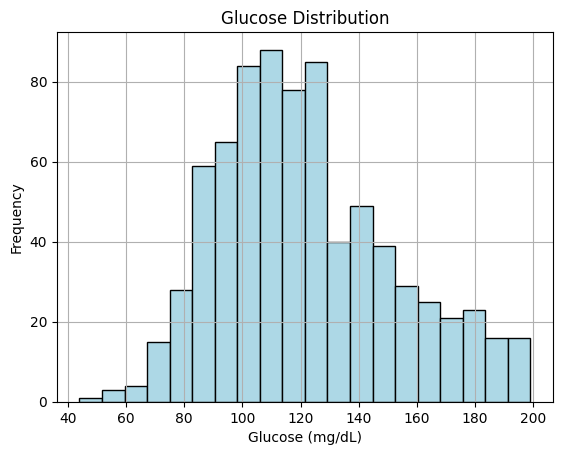

In [ ]:
# Distribution of Glucose in the dataset
df_prepared["Glucose"].hist(bins=20, color="lightblue", edgecolor="black")
plt.title("Glucose Distribution")
plt.xlabel("Glucose (mg/dL)")
plt.ylabel("Frequency")
plt.show()

**Interpretation:** Most patients have glucose readings between about 80 and 150 mg/dL, with the distribution peaking in the 100–130 mg/dL range. The distribution is right-skewed, with a smaller number of patients showing elevated glucose levels up to 200 mg/dL. This long right tail is consistent with the subset of patients who have diabetes, since elevated glucose is a defining feature of the condition.

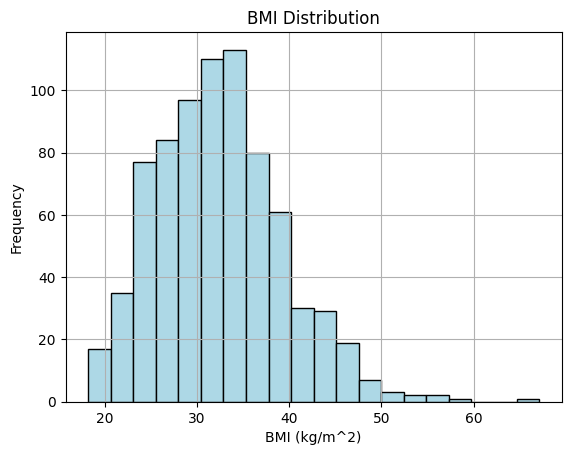

In [ ]:
# Distribution of BMI in the dataset
df_prepared["BMI"].hist(bins=20, color="lightblue", edgecolor="black")
plt.title("BMI Distribution")
plt.xlabel("BMI (kg/m^2)")
plt.ylabel("Frequency")
plt.show()

**Interpretation:** BMI values cluster between about 25 and 40 $\text{kg/m}^2$, peaking around 30–35 $\text{kg/m}^2$, which falls in the obese range by standard clinical cutoffs. The distribution is also right-skewed, with a smaller number of patients extending out past 50 $\text{kg/m}^2$ and one case near 65 $\text{kg/m}^2$. Combined with the glucose distribution above, this suggests the sample skews toward a higher-risk population rather than representing a general, healthy-weight group.

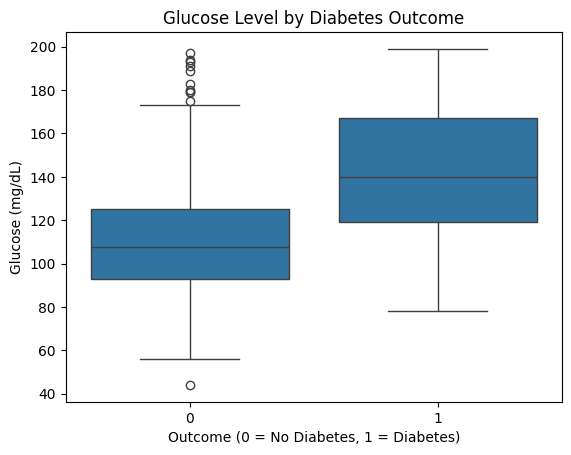

In [ ]:
# Bivariate visualization: Glucose by diabetes outcome
sns.boxplot(data=df_prepared, x="Outcome", y="Glucose")
plt.title("Glucose Level by Diabetes Outcome")
plt.xlabel("Outcome (0 = No Diabetes, 1 = Diabetes)")
plt.ylabel("Glucose (mg/dL)")
plt.show()

**Interpretation:** Patients with diabetes (Outcome = 1) have visibly higher and more variable glucose levels than patients without diabetes. This matches clinical expectations, since elevated glucose is a defining feature of diabetes.

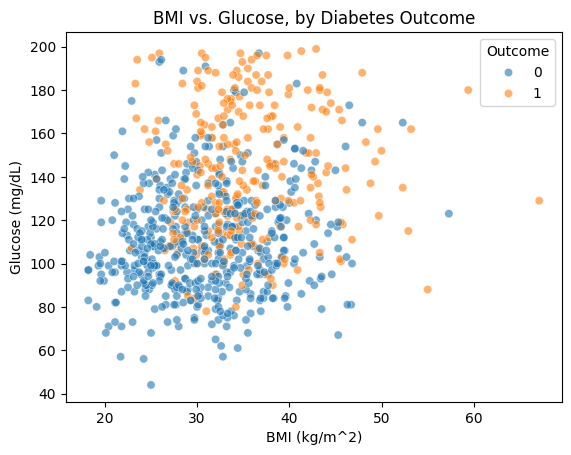

In [ ]:
# Bivariate visualization: BMI vs. Glucose, colored by outcome
sns.scatterplot(data=df_prepared, x="BMI", y="Glucose", hue="Outcome", alpha=0.6)
plt.title("BMI vs. Glucose, by Diabetes Outcome")
plt.xlabel("BMI (kg/m^2)")
plt.ylabel("Glucose (mg/dL)")
plt.legend(title="Outcome")
plt.show()

**Interpretation:** Patients with diabetes (`Outcome` = 1, shown in the second color) cluster toward the higher end of both `BMI` and `Glucose`, while patients without diabetes are concentrated at lower values of both. This is consistent with `BMI` and `Glucose` being related, overlapping risk factors rather than fully independent ones.

### Correlation Matrix

We use **Spearman rank correlation** rather than Pearson correlation here. Several variables in this dataset (e.g., `Insulin`, `Pregnancies`, `Pedigree`) are skewed rather than normally distributed, and `Outcome` is binary. Spearman correlation only assumes a monotonic relationship, which makes it more appropriate than Pearson for this mix of variable shapes.

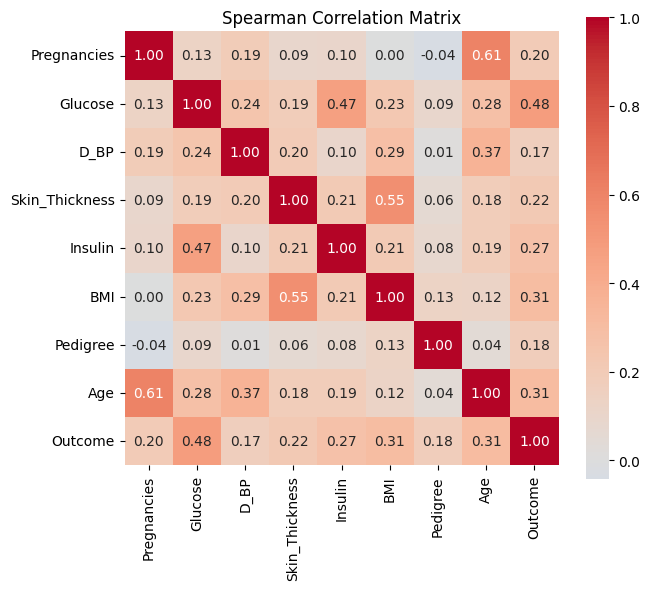

In [ ]:
correlation_matrix = df_prepared.corr(method="spearman")

plt.figure(figsize=(7, 6))
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap="coolwarm", center=0, square=True)
plt.title("Spearman Correlation Matrix")
plt.show()

**Interpretation:** `Glucose` has the strongest relationship with `Outcome` of any predictor ($\rho \approx 0.48$), consistent with the boxplot above; `Age` and `BMI` follow at a more moderate strength ($\rho \approx 0.31$ each). Among the predictors themselves, `Pregnancies` and `Age` are the most strongly related pair in the dataset ($\rho \approx 0.61$, older patients in this sample tend to have had more pregnancies), and `Skin_Thickness` and `BMI` are also strongly related ($\rho \approx 0.55$), which is expected since both partly reflect body fat. `Glucose` and `Insulin` are moderately related ($\rho \approx 0.47$), consistent with their shared role in glucose regulation. These are associations, not causal relationships, for example, the Pregnancies–Age correlation reflects that both increase over a patient's lifetime, not that one
causes the other, and none of these relationships establishes that a given predictor causes diabetes.

### Inferential Analysis

#### Two-Sample t-Test: Glucose by Diabetes Outcome

**Purpose:** test whether the average `Glucose` level differs between patients with and without
a diabetes diagnosis.

$$t = \frac{\bar{x}_1 - \bar{x}_2}{s_p\sqrt{\dfrac{1}{n_1}+\dfrac{1}{n_2}}}$$

where $\bar{x}_1$ and $\bar{x}_2$ are the group means, $n_1$ and $n_2$ are the group sizes, and
$s_p$ is the pooled standard deviation. This test evaluates whether an observed difference in
group means is larger than what would be expected from sampling variation alone, under the
assumption that `Glucose` is approximately normally distributed within each group.


In [ ]:
group_0 = df_prepared.loc[df_prepared["Outcome"] == 0, "Glucose"]
group_1 = df_prepared.loc[df_prepared["Outcome"] == 1, "Glucose"]

t_stat, p_value = ttest_ind(group_0, group_1)
print(f"Mean glucose (no diabetes): {group_0.mean():.2f} mg/dL")
print(f"Mean glucose (diabetes): {group_1.mean():.2f} mg/dL")
print("t-statistic:", t_stat)
print("p-value:", p_value)

Mean glucose (no diabetes): 110.68 mg/dL
Mean glucose (diabetes): 142.13 mg/dL
t-statistic: -15.673795182294105
p-value: 3.1287190418423694e-48


**Interpretation:** Average glucose is about 110 in patients without diabetes versus about 142 in patients with diabetes. The p-value is far below 0.05, so this difference is statistically significant, which indicates glucose level is strongly associated with diabetes outcome in this dataset.

#### Mann-Whitney U Test: BMI by Diabetes Outcome

**Purpose:** as a second inferential comparison, test whether `BMI` differs between the two outcome groups. A **Mann-Whitney U test** (the nonparametric counterpart to the t-test above) was
selected because `BMI`, like several variables in this dataset, is right-skewed rather than normally distributed. The Mann-Whitney U test compares the *ranks* of the two groups' values instead of assuming a particular distribution shape, which makes it more appropriate here than a second t-test.

$$U = n_1 n_2 + \frac{n_1(n_1+1)}{2} - R_1$$

where $n_1$ and $n_2$ are the two group sizes and $R_1$ is the sum of ranks in group 1, when all observations from both groups are ranked together. $U$ evaluates whether one group's values tend to rank higher than the other's, rather than comparing means directly.


In [ ]:
bmi_group_0 = df_prepared.loc[df_prepared["Outcome"] == 0, "BMI"]
bmi_group_1 = df_prepared.loc[df_prepared["Outcome"] == 1, "BMI"]

u_stat, u_p_value = mannwhitneyu(bmi_group_0, bmi_group_1, alternative="two-sided")
print(f"Median BMI (No diabetes): {bmi_group_0.median():.2f}")
print(f"Median BMI (Diabetes): {bmi_group_1.median():.2f}")
print(f"U-statistic: {u_stat:.1f}")
print(f"p-value:     {u_p_value:.3e}")

Median BMI (No diabetes): 30.40
Median BMI (Diabetes): 34.25
U-statistic: 42082.5
p-value:     1.844e-17


**Interpretation:** the p-value is far below 0.05, indicating that BMI values are significantly higher, in rank terms, among patients diagnosed with diabetes (median 34.25) than among those without a diagnosis (median 30.40). Combined with the t-test result above, both Glucose and BMI show a statistically significant association with diabetes diagnosis in this sample, with Glucose showing the larger effect.

### Data, Statistics, and the Machine Learning Workflow

### Formalizing the Statistical and Machine Learning Problem

In biostatistics and supervised machine learning, we begin with a dataset consisting of observations (examples) and their corresponding target labels. We denote the dataset as:

$$
\mathcal{D} = \{(x_i,y_i)\}_{i=1}^{n},
\qquad
x_i \in \mathbb{R}^{p},
\qquad
y_i \in \{0,1\}.
$$

where:

- $\mathcal{D}$ denotes the complete dataset.
- $n = 768$ is the total number of observations (rows) in the dataset.
- $i$ represents the index of an individual observation, where $i = 1,2,\ldots,n$.
- $x_i$ is the feature vector (predictor variables) corresponding to the $i^{th}$ observation.
- $p=8$ is the total number of predictor (feature) variables.
- $\mathbb{R}^{p}$ denotes the 8-dimensional real-valued feature space these predictors occupy.
- $y_i$ is the target (response) variable associated with observation $i$: wheather that patient was diagnosed with diabetes.
- $\{0,1\}$ indicates that this is a **binary classification** problem, where:
  - $0$ represents a patient with no diabetes.
  - $1$ represents a patient with diabetes.

For the diabetes dataset used in this notebook, the 8 predictor variables and the target are:

$$
x_i =
\begin{bmatrix}
\text{Pregnancies} \\
\text{Glucose} \\
\text{D_BP} \\
\text{Skin_Thickness} \\
\text{Insulin} \\
\text{BMI} \\
\text{Pedigree} \\
\text{Age}
\end{bmatrix},
\qquad
y_i = \text{Outcome}.
$$

Thus, each patient is represented by a vector of the 8 predictor variables, and the machine learning algorithm would learn an estimated prediction function:

$$
\hat{f}: \mathbb{R}^{8} \rightarrow \{0,1\},
$$

where:

- $\hat{f}$ (pronounced *"f-hat"*) denotes the **estimated prediction function** learned from the training data.
- The "hat" indicates that the function is an **estimate** of the unknown relationship between the predictor variables and the target variable.

The function $\hat{f}(\cdot)$ maps a patient's 8 predictor values to a predicted `Outcome`.

The objective of supervised learning is to estimate the function $\hat{f}(\cdot)$ so that it accurately predicts the `Outcome` for patients that were **not** used during model training.

### Reproducibility Check

In [ ]:
# A small random participant sample used during review
df_prepared.sample(8, random_state=RANDOM_SEED)

,Pregnancies,Glucose,D_BP,Skin_Thickness,Insulin,BMI,Pedigree,Age,Outcome
668,6,98.0,58.0,33.0,190.0,34.0,0.430,43,0
324,2,112.0,75.0,32.0,125.0,35.7,0.148,21,0
624,2,108.0,64.0,29.0,125.0,30.8,0.158,21,0
690,8,107.0,80.0,29.0,125.0,24.6,0.856,34,0
473,7,136.0,90.0,29.0,125.0,29.9,0.210,50,0
204,6,103.0,72.0,32.0,190.0,37.7,0.324,55,0
97,1,71.0,48.0,18.0,76.0,20.4,0.323,22,0
336,0,117.0,72.0,29.0,125.0,33.8,0.932,44,0


In [ ]:
# Bootstrap estimate used during exploratory review
bootstrap_mean_bmi = df_prepared["BMI"].sample(n=len(df_prepared), replace=True, random_state=RANDOM_SEED).mean()
print(f"Bootstrap mean BMI: {bootstrap_mean_bmi:.2f}")

Bootstrap mean BMI: 31.93


## Results and Conclusions

Add a concise summary of the major analytical findings and any important limitations.

## Results

**Key findings:**
- Glucose shows the strongest association with diabetes outcome. Patients with diabetes average 142 mg/dL versus 110 mg/dL in patients without diabetes, a significant difference by t-test (p < 0.001) and the strongest Spearman correlation with Outcome
  ($\rho \approx 0.48$).
- BMI is also significantly associated with outcome. Median BMI is 34.25 in diabetic patients versus 30.40 in non-diabetic patients, confirmed by a Mann-Whitney U test (p < 0.001) given BMI's skewed distribution.
- Age shows a similar moderate correlation with outcome to BMI ($\rho \approx 0.31$).
- Among the predictors themselves, Pregnancies and Age are the most strongly related pair ($\rho \approx 0.61$), and Skin_Thickness and BMI are also strongly related ($\rho \approx 0.55$), consistent with both reflecting body fat.
- Glucose and Insulin are moderately correlated ($\rho \approx 0.47$), consistent with their shared role in glucose regulation.

## Conclusions

Glucose and BMI are the two clinical measurements most associated with diabetes outcome in this dataset, which lines up with established diabetes risk factors. These results are associations from a single cross-sectional dataset, not evidence of causation.

Limitations:
- Insulin and Skin_Thickness had the most missing values (374 and 227 out of 768), recoded from implausible zeros and filled using median imputation. This is simple and reproducible, but understates the true variability in those columns, so results involving Insulin and Skin_Thickness should be read with that in mind.
- The dataset includes only female patients, so findings may not generalize to other populations.
- All relationships reported are correlational, not causal.